# 05 Dynamic Early Warning

This experiment keeps the audited 38 process-only candidate variables and the 04 evaluation definition. A is the 04 static Mahalanobis baseline. B adds a 10-second first-difference rate. C adds 30/60/120-second full-window slopes.

All feature scaling, covariance fitting, and the 0.995 threshold use only the single fixed-power Normal reference. A detection is confirmed after three consecutive above-threshold samples; negative lead time means confirmation came after first protection.

Because there is only one Normal trajectory, Normal false-alarm results are in-sample point/run diagnostics, not an independent false-alarm rate. The 120-second slope group cannot produce valid scores before 120 seconds, and its earliest three-sample confirmation is 140 seconds.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next((candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / 'src').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Run this notebook from the NPP-Guard repository or one of its subdirectories.')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from data_loader import DEFAULT_LOCA_DIR, DEFAULT_NORMAL_FILE
from early_anomaly_detection import evaluate_reference
from dynamic_features import (
    GROUP_DELTA,
    GROUP_SLOPE,
    GROUP_STATIC,
    evaluate_dynamic_group,
)
from features import build_loca_event_table, candidate_pre_protection_features

RESULTS_ROOT = PROJECT_ROOT / 'results'
FIGURES_ROOT = RESULTS_ROOT / 'figures'
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)
normal = pd.read_csv(DEFAULT_NORMAL_FILE)
events_path = RESULTS_ROOT / 'loca_event_table.csv'
events = pd.read_csv(events_path) if events_path.exists() else build_loca_event_table()
candidate_features = candidate_pre_protection_features()
assert len(candidate_features) == 38
assert len(events) == 100 and events['first_protection_s'].notna().all()
assert events['injection_s'].nunique() == 1 and float(events['injection_s'].iloc[0]) == 0.5
assert np.allclose(normal['TIME'].diff().dropna().to_numpy(), 10.0)
print('Project:', PROJECT_ROOT)
print('Normal rows:', len(normal), 'LOCA cases:', len(events))
print('Audited candidate features:', len(candidate_features))

Project: C:\Users\18205\NPP-Guard
Normal rows: 302 LOCA cases: 100
Audited candidate features: 38


## A: 04 static Mahalanobis baseline

In [2]:
_, static_all_results, static_all_summary = evaluate_reference(
    normal=normal,
    loca_dir=DEFAULT_LOCA_DIR,
    events=events,
    candidate_features=candidate_features,
)
a_results = static_all_results.loc[static_all_results['method'].eq('mahalanobis')].copy()
a_results.insert(2, 'feature_group', GROUP_STATIC)
a_results['earliest_valid_feature_time_s'] = 0.0
a_results['earliest_possible_confirmed_alarm_s'] = 30.0
a_summary = static_all_summary.loc[static_all_summary['method'].eq('mahalanobis')].copy()
a_summary.insert(0, 'feature_group', GROUP_STATIC)
a_summary['base_candidate_feature_count'] = len(candidate_features)
a_summary['calibration_start_s'] = 0.0
a_summary['calibration_end_s'] = 100.0
a_summary['feature_warmup_s'] = 0.0
a_summary['earliest_possible_confirmed_alarm_s'] = 30.0
display(a_summary)

,feature_group,method,candidate_feature_count,active_feature_count,inactive_near_zero_feature_count,calibration_rows,threshold_quantile,threshold,pca_components,covariance_condition_number,...,lead_time_min_s,lead_time_max_s,normal_reference_alarm_time_s,normal_reference_false_alarm,normal_points_above_threshold,base_candidate_feature_count,calibration_start_s,calibration_end_s,feature_warmup_s,earliest_possible_confirmed_alarm_s
1,A_static,mahalanobis,38,30,8,11,0.995,151.414978,2,74.338554,...,-115.0,20.5,NaN,False,2,38,0.0,100.0,0.0,30.0


## B/C: add dynamics while keeping calibration Normal-only

In [3]:
dynamic_results = []
dynamic_summaries = []
dynamic_models = {}
for feature_group in (GROUP_DELTA, GROUP_SLOPE):
    model, group_results, group_summary = evaluate_dynamic_group(
        normal=normal,
        loca_dir=DEFAULT_LOCA_DIR,
        events=events,
        candidate_features=candidate_features,
        feature_group=feature_group,
    )
    dynamic_models[feature_group] = model
    dynamic_results.append(group_results)
    dynamic_summaries.append(group_summary)

b_results, c_results = dynamic_results
b_summary, c_summary = dynamic_summaries
print('B active features:', len(dynamic_models[GROUP_DELTA].active_features))
print('C active features:', len(dynamic_models[GROUP_SLOPE].active_features))
display(pd.concat([b_summary, c_summary], ignore_index=True))

C:\Users\18205\NPP-Guard\src\dynamic_features.py:132: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f"slope{label}s__{feature}"] = _rolling_slope(


C:\Users\18205\NPP-Guard\src\dynamic_features.py:132: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f"slope{label}s__{feature}"] = _rolling_slope(


C:\Users\18205\NPP-Guard\src\dynamic_features.py:132: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f"slope{label}s__{feature}"] = _rolling_slope(


B active features: 60
C active features: 150


,feature_group,method,base_candidate_feature_count,candidate_feature_count,active_feature_count,inactive_near_zero_feature_count,calibration_rows,calibration_start_s,calibration_end_s,feature_warmup_s,...,protection_before_detected_rate,detection_time_median_s,detection_time_min_s,detection_time_max_s,lead_time_median_s,lead_time_min_s,lead_time_max_s,normal_reference_alarm_time_s,normal_reference_false_alarm,normal_points_above_threshold
0,B_static_delta,mahalanobis,38,76,60,16,301,10.0,3010.0,10.0,...,0.0,150.0,140.0,2060.0,-24.25,-115.0,-20.0,NaN,False,2
1,C_static_delta_slope,mahalanobis,38,190,150,40,290,120.0,3010.0,120.0,...,0.0,150.0,140.0,2060.0,-24.25,-115.0,-20.0,NaN,False,2


## Combined results and checks

The static row is the 04 Mahalanobis result, so the A row is intentionally the same baseline rather than a separately tuned 05 model. B and C use the same continuous-alarm rule and score only after their feature warm-up.

In [4]:
results = pd.concat([a_results, b_results, c_results], ignore_index=True, sort=False)
summary = pd.concat([a_summary, b_summary, c_summary], ignore_index=True, sort=False)
summary = summary.assign(
    feature_group=pd.Categorical(
        summary['feature_group'], categories=[GROUP_STATIC, GROUP_DELTA, GROUP_SLOPE], ordered=True
    )
).sort_values('feature_group').reset_index(drop=True)
results = results.sort_values(['feature_group', 'severity']).reset_index(drop=True)

results_path = RESULTS_ROOT / 'dynamic_early_warning_results.csv'
summary_path = RESULTS_ROOT / 'dynamic_early_warning_method_summary.csv'
results.to_csv(results_path, index=False)
summary.to_csv(summary_path, index=False)

assert set(results['feature_group'].astype(str)) == {GROUP_STATIC, GROUP_DELTA, GROUP_SLOPE}
assert results.groupby('feature_group', observed=True).size().eq(100).all()
assert results['first_protection_time_s'].notna().all()
assert summary['threshold'].notna().all() and np.isfinite(summary['threshold']).all()
for feature_group, warmup in ((GROUP_DELTA, 10.0), (GROUP_SLOPE, 120.0)):
    detected = results.loc[results['feature_group'].eq(feature_group), 'detection_time_s'].dropna()
    assert (detected >= warmup + 20.0).all()

display(summary[[
    'feature_group', 'active_feature_count', 'calibration_rows', 'feature_warmup_s',
    'earliest_possible_confirmed_alarm_s', 'threshold', 'detected_count',
    'protection_before_detected_count', 'protection_before_detected_rate',
    'detection_time_median_s', 'lead_time_median_s', 'lead_time_min_s',
    'lead_time_max_s', 'normal_reference_false_alarm',
    'normal_points_above_threshold'
]])
print('Saved:', results_path.relative_to(PROJECT_ROOT))
print('Saved:', summary_path.relative_to(PROJECT_ROOT))

,feature_group,active_feature_count,calibration_rows,feature_warmup_s,earliest_possible_confirmed_alarm_s,threshold,detected_count,protection_before_detected_count,protection_before_detected_rate,detection_time_median_s,lead_time_median_s,lead_time_min_s,lead_time_max_s,normal_reference_false_alarm,normal_points_above_threshold
0,A_static,30,11,0.0,30.0,151.414978,100,2,0.02,150.0,-25.25,-115.0,20.5,False,2
1,B_static_delta,60,301,10.0,30.0,5.227520,100,0,0.00,150.0,-24.25,-115.0,-20.0,False,2
2,C_static_delta_slope,150,290,120.0,140.0,10.370545,100,0,0.00,150.0,-24.25,-115.0,-20.0,False,2


Saved: results\dynamic_early_warning_results.csv
Saved: results\dynamic_early_warning_method_summary.csv


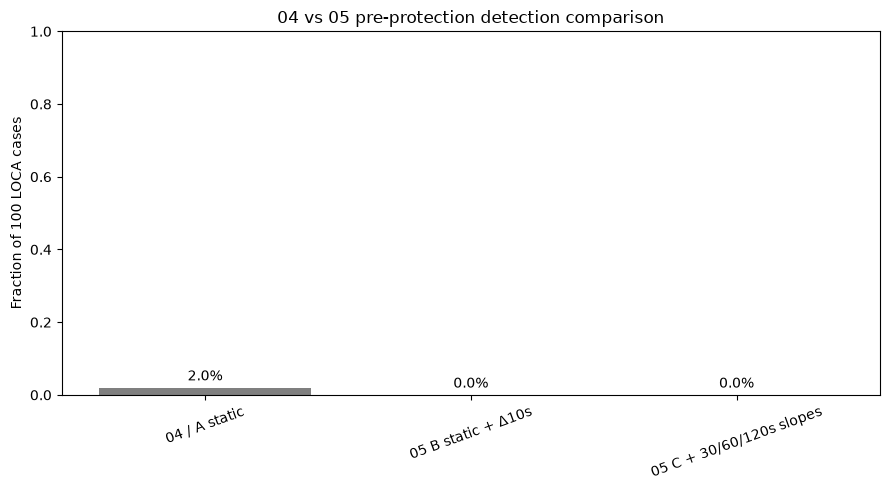

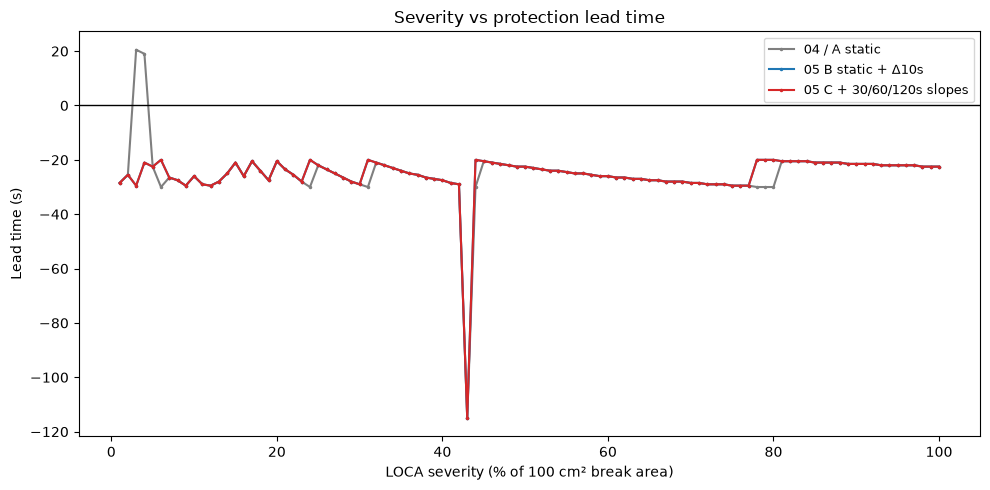

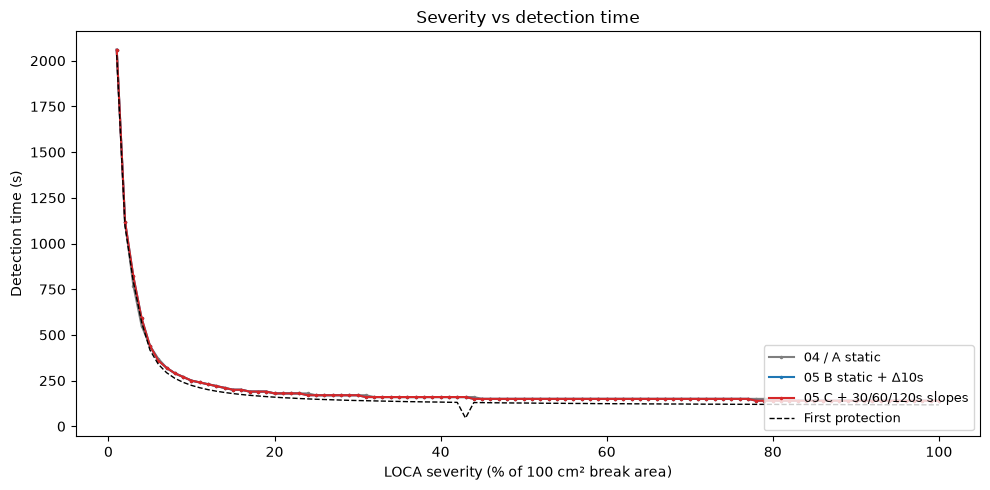

Figures: ['05_04_vs_05_preprotection_comparison.png', '05_severity_vs_lead_time.png', '05_severity_vs_detection_time.png']


In [5]:
labels = {
    GROUP_STATIC: '04 / A static',
    GROUP_DELTA: '05 B static + Δ10s',
    GROUP_SLOPE: '05 C + 30/60/120s slopes',
}
colors = {GROUP_STATIC: '#7f7f7f', GROUP_DELTA: '#1f77b4', GROUP_SLOPE: '#d62728'}
ordered_groups = [GROUP_STATIC, GROUP_DELTA, GROUP_SLOPE]

fig, ax = plt.subplots(figsize=(9, 5))
plot_summary = summary.set_index('feature_group').loc[ordered_groups]
bars = ax.bar(
    [labels[group] for group in ordered_groups],
    plot_summary['protection_before_detected_rate'],
    color=[colors[group] for group in ordered_groups],
)
for bar, value in zip(bars, plot_summary['protection_before_detected_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.1%}', ha='center')
ax.set(ylim=(0, 1), ylabel='Fraction of 100 LOCA cases', title='04 vs 05 pre-protection detection comparison')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIGURES_ROOT / '05_04_vs_05_preprotection_comparison.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for group in ordered_groups:
    part = results.loc[results['feature_group'].eq(group)]
    ax.plot(part['severity'], part['lead_time_s'], '.-', ms=3, label=labels[group], color=colors[group])
ax.axhline(0, color='black', lw=1)
ax.set(xlabel='LOCA severity (% of 100 cm² break area)', ylabel='Lead time (s)', title='Severity vs protection lead time')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_ROOT / '05_severity_vs_lead_time.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for group in ordered_groups:
    part = results.loc[results['feature_group'].eq(group)]
    ax.plot(part['severity'], part['detection_time_s'], '.-', ms=3, label=labels[group], color=colors[group])
if GROUP_STATIC in results['feature_group'].astype(str).unique():
    part = results.loc[results['feature_group'].eq(GROUP_STATIC)]
    ax.plot(part['severity'], part['first_protection_time_s'], '--', color='black', lw=1, label='First protection')
ax.set(xlabel='LOCA severity (% of 100 cm² break area)', ylabel='Detection time (s)', title='Severity vs detection time')
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_ROOT / '05_severity_vs_detection_time.png', dpi=160)
plt.show()
print('Figures:', [
    '05_04_vs_05_preprotection_comparison.png',
    '05_severity_vs_lead_time.png',
    '05_severity_vs_detection_time.png',
])

In [6]:
low_severity = results.loc[results['severity'].le(10)].pivot(
    index='severity', columns='feature_group',
    values=['detection_time_s', 'first_protection_time_s', 'lead_time_s', 'detected_before_protection'],
)
display(low_severity)

normal_checks = summary[[
    'feature_group', 'normal_reference_alarm_time_s',
    'normal_reference_false_alarm', 'normal_points_above_threshold'
]]
display(normal_checks)
print('Interpretation: Normal diagnostics are in-sample because there is one fixed-power Normal trajectory.')

detection_time_s                                      \
feature_group         A_static B_static_delta C_static_delta_slope   
severity                                                             
1                       2060.0         2060.0               2060.0   
2                       1120.0         1120.0               1120.0   
3                        770.0          820.0                820.0   
4                        550.0          590.0                590.0   
5                        440.0          440.0                440.0   
6                        370.0          360.0                360.0   
7                        320.0          320.0                320.0   
8                        290.0          290.0                290.0   
9                        270.0          270.0                270.0   
10                       250.0          250.0                250.0   

              first_protection_time_s                                      \
feature_group                A_static B_static_delta C_static_delta_slope   
severity                                                                    
1                              2031.5         2031.5               2031.5   
2                              1094.5         1094.5               1094.5   
3                               790.5          790.5                790.5   
4                               569.0          569.0                569.0   
5                               417.5          417.5                417.5   
6                               340.0          340.0                340.0   
7                               293.5          293.5                293.5   
8                               262.5          262.5                262.5   
9                               240.5          240.5                240.5   
10                              224.0          224.0                224.0   

              lead_time_s                                      \
feature_group    A_static B_static_delta C_static_delta_slope   
severity                                                        
1                   -28.5          -28.5                -28.5   
2                   -25.5          -25.5                -25.5   
3                    20.5          -29.5                -29.5   
4                    19.0          -21.0                -21.0   
5                   -22.5          -22.5                -22.5   
6                   -30.0          -20.0                -20.0   
7                   -26.5          -26.5                -26.5   
8                   -27.5          -27.5                -27.5   
9                   -29.5          -29.5                -29.5   
10                  -26.0          -26.0                -26.0   

              detected_before_protection                                      
feature_group                   A_static B_static_delta C_static_delta_slope  
severity                                                                      
1                                  False          False                False  
2                                  False          False                False  
3                                   True          False                False  
4                                   True          False                False  
5                                  False          False                False  
6                                  False          False                False  
7                                  False          False                False  
8                                  False          False                False  
9                                  False          False                False  
10                                 False          False                False

,feature_group,normal_reference_alarm_time_s,normal_reference_false_alarm,normal_points_above_threshold
0,A_static,NaN,False,2
1,B_static_delta,NaN,False,2
2,C_static_delta_slope,NaN,False,2


Interpretation: Normal diagnostics are in-sample because there is one fixed-power Normal trajectory.
